# Tarea-Práctica 3 — Graficación en Python

**Física Computacional — Grupo 8270**  
**Semestre 2027-1**



# 1. Gráfica de datos experimentales

El archivo `manchasolares.txt` contiene dos columnas: la primera corresponde al mes y la segunda al número de manchas solares observadas.

### (a) Graficar las manchas solares en función del tiempo

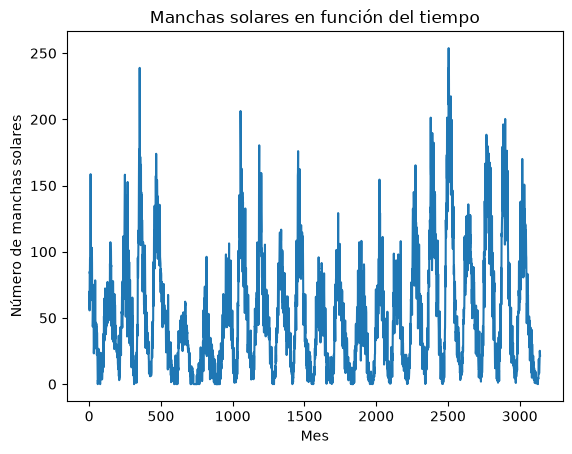

In [11]:
import numpy as np
import matplotlib.pyplot as plt

datos = np.loadtxt("manchasolares.txt")

mes = datos[:, 0]
manchas = datos[:, 1]

plt.plot(mes, manchas)

plt.xlabel("Mes")
plt.ylabel("Número de manchas solares")
plt.title("Manchas solares en función del tiempo")

plt.show() 

### (b) Primeros 1000 datos

Ahora modificamos el programa para mostrar solamente los primeros 1000 datos experimentales.

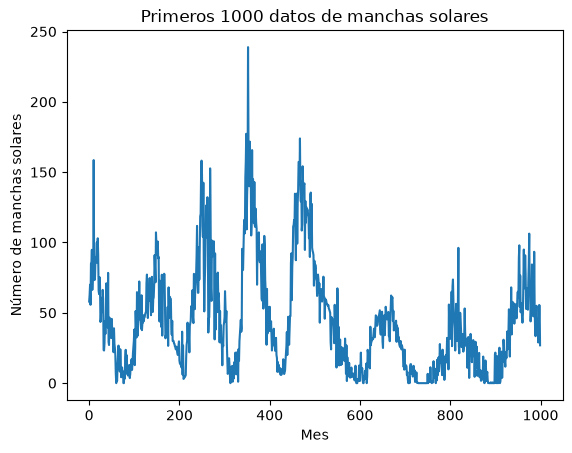

In [12]:
import numpy as np
import matplotlib.pyplot as plt

datos = np.loadtxt("manchasolares.txt")

mes = datos[:1000, 0]
manchas = datos[:1000, 1]

plt.plot(mes, manchas)

plt.xlabel("Mes")
plt.ylabel("Número de manchas solares")
plt.title("Primeros 1000 datos de manchas solares")

plt.show()

### (c) Media móvil

Modifica nuevamente tu programa para calcular y graficar la media (promedio)
móvil de los datos, definida por:

$$
Y_k = \frac{1}{2r+1}\sum_{m=-r}^{r}y_{k+m},
$$

con $r=5$.

donde r = 5 (en este caso) y yk son los numeros de manchas solares.  ́El programa debe graficar tanto los datos originales como la media móvil en el
mismo gráfico, sólo sobre los primeros 1000 datos.  

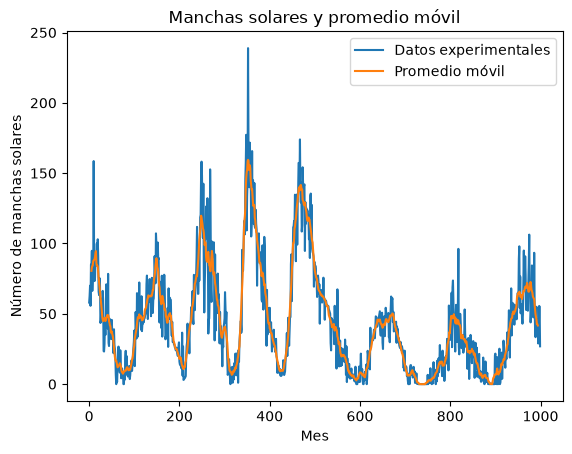

In [13]:
import numpy as np
import matplotlib.pyplot as plt

datos = np.loadtxt("manchasolares.txt")

mes = datos[:1000, 0]
manchas = datos[:1000, 1]

r = 5

promedio = []

for i in range(r, len(manchas) - r):
    suma = 0
    
    for j in range(-r, r + 1):
        suma = suma + manchas[i + j]
    
    promedio.append(suma / (2 * r + 1))

mes_promedio = mes[r:len(manchas) - r]

plt.plot(mes, manchas, label="Datos experimentales")
plt.plot(mes_promedio, promedio, label="Promedio móvil")

plt.xlabel("Mes")
plt.ylabel("Número de manchas solares")
plt.title("Manchas solares y promedio móvil")

plt.legend()
plt.show()

# 2. Gráfica de Feigenbaum

El mapeo logístico está definido por

$$
x_{n+1}=rx_n(1-x_n).
$$

Para cada valor de $r$ entre 1 y 4, con pasos de 0.01, comenzamos con $x_0=1/2$, hacemos 1000 iteraciones para permitir que el sistema se establezca y después graficamos otras 1000 iteraciones.

### (a) Programa para obtener el diagrama de Feigenbaum

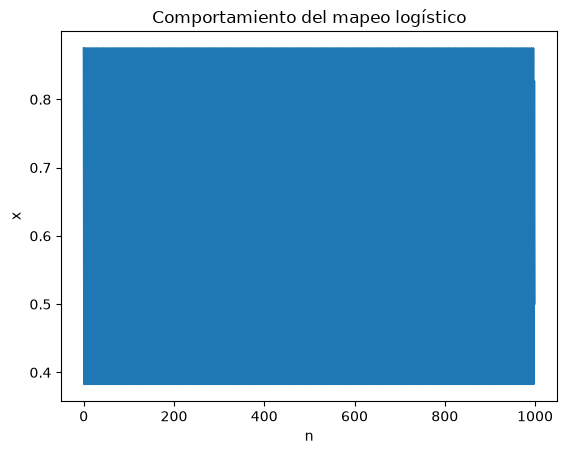

In [14]:
import numpy as np
import matplotlib.pyplot as plt

r = 3.5

x = 0.5

valores = []

for n in range(1000):
    x = r * x * (1 - x)
    valores.append(x)

plt.plot(valores)

plt.xlabel("n")
plt.ylabel("x")
plt.title("Comportamiento del mapeo logístico")

plt.show()


### (b) Borde del caos

En la gráfica se observa que el sistema comienza con comportamiento ordenado y, conforme aumenta $r$, aparecen bifurcaciones hasta llegar al régimen caótico.

**Respuesta:** el paso al comportamiento caótico ocurre aproximadamente en

$$
r \approx 3.57.
$$

Este valor corresponde aproximadamente al límite de acumulación de las bifurcaciones del mapeo logístico.

C:\Users\anast\AppData\Local\Temp\ipykernel_19320\630856252.py:14: RuntimeWarning: overflow encountered in scalar multiply
  x = r * x * (1 - x)


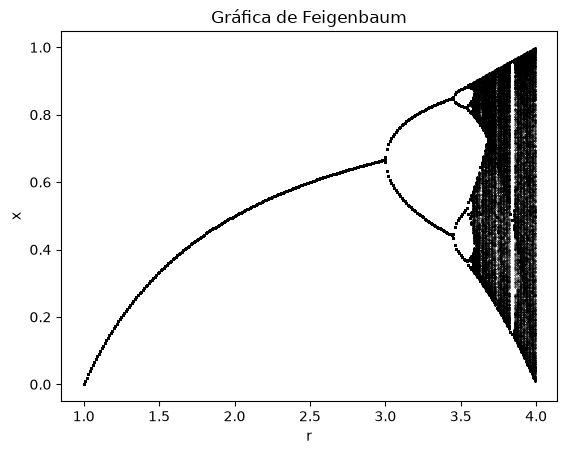

In [18]:
import numpy as np
import matplotlib.pyplot as plt

rvalores = np.arange(1, 4.01, 0.01)

r_grafica = []
x_grafica = []

for r in rvalores:

    x = 0.5

    for n in range(1000):
        x = r * x * (1 - x)

    for n in range(1000):
        x = r * x * (1 - x)
        r_grafica.append(r)
        x_grafica.append(x)

plt.plot(r_grafica, x_grafica, "k.", markersize=0.5)

plt.xlabel("r")
plt.ylabel("x")
plt.title("Gráfica de Feigenbaum")

plt.show()

### (c) Opcional — versión con arreglos

Esta versión aprovecha las operaciones con arreglos de NumPy para realizar una iteración para todos los valores de $r$ simultáneamente.

C:\Users\anast\AppData\Local\Temp\ipykernel_19320\3155371969.py:9: RuntimeWarning: overflow encountered in multiply
  x = r * x * (1 - x)


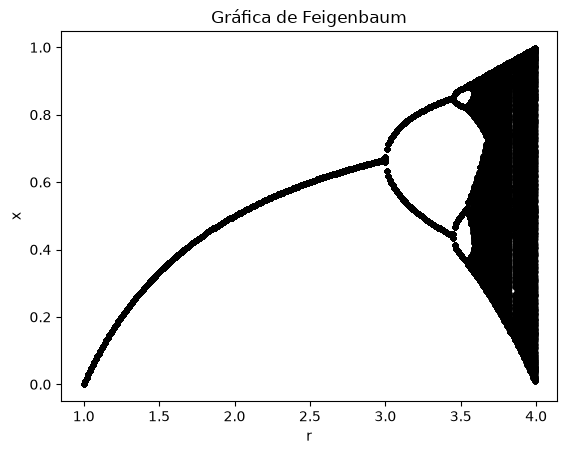

In [20]:
import numpy as np
import matplotlib.pyplot as plt

r = np.arange(1, 4.01, 0.01)

x = np.ones(len(r)) * 0.5

for n in range(1000):
    x = r * x * (1 - x)

for n in range(1000):
    x = r * x * (1 - x)
    plt.plot(r, x, "k.")

plt.xlabel("r")
plt.ylabel("x")
plt.title("Gráfica de Feigenbaum")

plt.show()

# 3. Conjunto de Mandelbrot

El conjunto de Mandelbrot se obtiene mediante la iteración

$$
z_{n+1}=z_n^2+c,
$$

donde $z_n$ y $c$ son números complejos.

Se comienza con

$$
z_0=0.
$$

Si durante la iteración se cumple

$$
|z_n|>2,
$$

el punto correspondiente a $c$ no pertenece al conjunto. Si después de un número suficientemente grande de iteraciones nunca supera 2, lo consideramos parte del conjunto.

### (a) Imagen en blanco y negro

Primero probaremos con una cuadrícula pequeña ($N=100$) y posteriormente podemos aumentar $N$ para obtener una imagen de mayor calidad.

C:\Users\anast\AppData\Local\Temp\ipykernel_19320\388205325.py:14: RuntimeWarning: overflow encountered in square
  Z = Z**2 + C
C:\Users\anast\AppData\Local\Temp\ipykernel_19320\388205325.py:14: RuntimeWarning: invalid value encountered in square
  Z = Z**2 + C


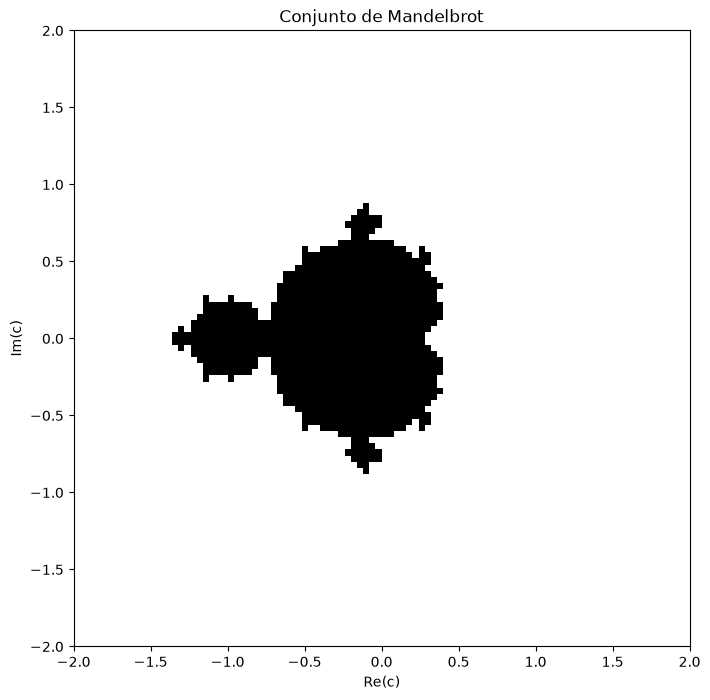

In [27]:
N = 100
max_iter = 100

x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)
X, Y = np.meshgrid(x, y)
C = X + 1j*Y

Z = np.zeros_like(C)

dentro = np.ones(C.shape, dtype=bool)

for i in range(max_iter):
    Z = Z**2 + C

    dentro[np.abs(Z) > 2] = False

plt.figure(figsize=(8, 8))
plt.imshow(dentro, extent=[-2, 2, -2, 2], origin="lower", cmap="gray_r")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.title("Conjunto de Mandelbrot")
plt.show()

### Imagen final con mayor resolución

Una vez comprobado que el programa funciona, podemos aumentar el valor de $N$ para obtener una imagen de mayor calidad.

C:\Users\anast\AppData\Local\Temp\ipykernel_19320\3972502955.py:13: RuntimeWarning: overflow encountered in square
  Z = Z**2 + C
C:\Users\anast\AppData\Local\Temp\ipykernel_19320\3972502955.py:13: RuntimeWarning: invalid value encountered in square
  Z = Z**2 + C


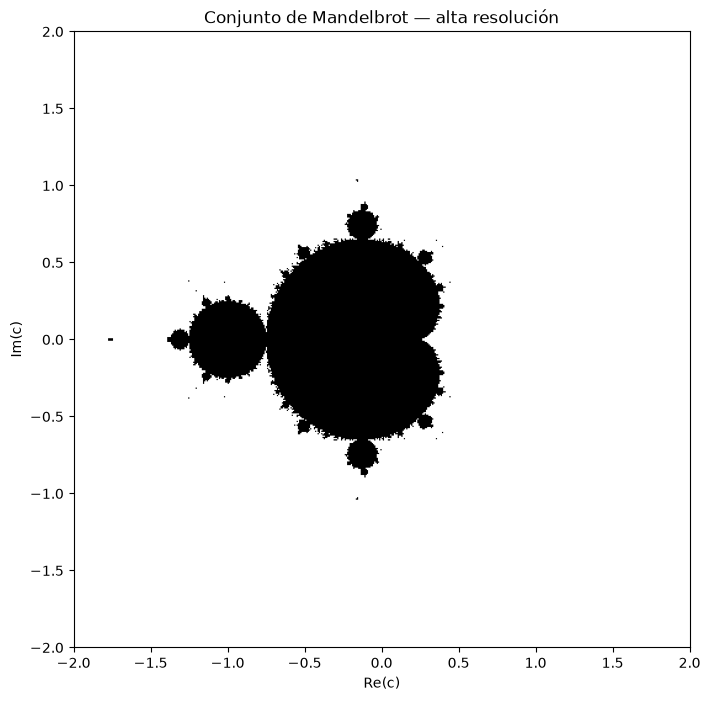

In [23]:
N = 500
max_iter = 100

x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)
X, Y = np.meshgrid(x, y)
C = X + 1j*Y

Z = np.zeros_like(C)
dentro = np.ones(C.shape, dtype=bool)

for i in range(max_iter):
    Z = Z**2 + C
    dentro[np.abs(Z) > 2] = False

plt.figure(figsize=(8, 8))
plt.imshow(dentro, extent=[-2, 2, -2, 2], origin="lower", cmap="gray_r")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.title("Conjunto de Mandelbrot — alta resolución")
plt.show()

### (b) Opcional — colorear según el número de iteraciones



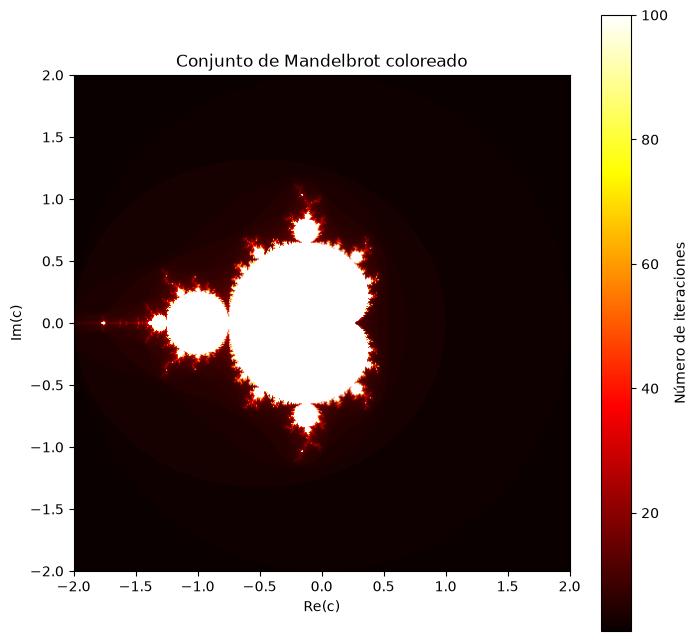

In [26]:
N = 500
max_iter = 100

x = np.linspace(-2, 2, N)
y = np.linspace(-2, 2, N)
X, Y = np.meshgrid(x, y)
C = X + 1j*Y

Z = np.zeros_like(C)
iteraciones = np.zeros(C.shape, dtype=int)
activos = np.ones(C.shape, dtype=bool)

for i in range(max_iter):
    Z[activos] = Z[activos]**2 + C[activos]

    escaparon = activos & (np.abs(Z) > 2)
    iteraciones[escaparon] = i + 1
    activos[escaparon] = False


iteraciones[activos] = max_iter

plt.figure(figsize=(8, 8))
plt.imshow(iteraciones, extent=[-2, 2, -2, 2], origin="lower", cmap="hot")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.title("Conjunto de Mandelbrot coloreado")
plt.colorbar(label="Número de iteraciones")
plt.show()